In [217]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Setting a clean plotting style for academic reports
plt.style.use('seaborn-v0_8-whitegrid')

Section 1:Data Loading and Preprocessing

In [218]:
def load_and_flatten_data(file_path, image_size=(96,96), has_labels=True):
  #This loads the images, resizes, flattens and normalises them for ML
  data = np.load(file_path)
  raw_images = data['images']

  flat_images = []
  for img in raw_images:
    resized = cv2.resize(img, image_size)
    #Resizes to a consistent 96x96 grid so all the input vectors are the exact same length

    normalized = resized.astype(np.float32) / 255.0
    #Normalising the pixel values between 0.0 and 1.0

    flat_images.append(normalized.flatten())
    #Flattens the 2d image matrix into a 1D array

  flat_images = np.array(flat_images)

  if has_labels:
    #The points are stored as 2d coordinates (X,Y).
    #Now we flatten them into a single 1d array per image so it can be seen as a sequence
    flat_points = data['points'].reshape(data['points'].shape[0], -1)
    return flat_images, flat_points, raw_images

  return flat_images, raw_images

Section 2:Model Definitions

In [219]:
def build_advanced_model():
  # Approach 1: Raw Pixels to Ridge Regression
  # alpha 1.0 stops the model from just memorising the noisy training images, which helps perform better on new faces
  return Ridge(alpha=1.0)

def build_advanced_model():
# Approach 2:PCA Feature Extraction to Ridge Regression
# A pipeline connects the steps together
  return Pipeline([
    # First step is to shrink down the image to just the 150 most important facial features.
    ('pca', PCA(n_components=150, random_state=42)),

    #The next step is using those 150 features to figure out where the dots will be placed.
    ('ridge', Ridge(alpha=0.5))
])



Section 3:Evaluation Metrics

In [220]:
def calculate_nme(y_true_flat, y_pred_flat):
  # Calculates the Mean Error for each image
  # This reshapes the flat arrays back into paris of (X, Y) coordinates for accurate math
  y_true_reshaped = y_true_flat.reshape(y_true_flat.shape[0], -1, 2)
  y_pred_reshaped = y_pred_flat.reshape(y_pred_flat.shape[0], -1, 2)

  # Measures the physical pixel distance between where the model guessed, and where the actual true point lies
  distance = np.linalg.norm(y_true_reshaped - y_pred_reshaped, axis=2)

  # Measures the physical pixel distance between where the model guessed, and where the actual true point lies
  np.linalg.norm(y_true_reshaped - y_pred_reshaped, axis=2)

  # Averaging the distances to get one single error score per face
  return np.mean(distance, axis=1)

def print_polished_results(model_name, nme_errors, threshold=0.10):
  mean_error = np.mean(nme_errors)

  # Calculating the success rate of what percentages of images had an error smaller than the allowed limit
  accuracy = np.mean(nme_errors < threshold) * 100




Section 4:Visualisatoin Functions

In [221]:
def plot_validation_results(baseline_errors, advanced_errors):
  #This draws two graphs side by side to compare the models
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # Graph 1: Line Chart (Cumulative Error)
  # This shows what percentage of images fall under the certain error limit
  for errors, label, color, style in zip(
      [baseline_errors, advanced_errors],
      ['Baseline (raw pixels)' , 'Advanced (PCA + Ridge)'],
      ['#e74c3c', '#2980b9'],  ['--', '-']):

  # This orders the errors from smallest to largest so the line goes up smoothly
    sorted_errs= np.sort(errors)
    yvals = np.arange(1, len(errors) + 1) / len(errors)
    axes[0].plot(sorted_errs, yvals, label=label, color=color, linestyle=style, linewidth=2)

# Plotting everything needed for a graph
  axes[0].set_title('Cumulative Error Distribution (CED)', fontsize=14, fontweight='bold')
  axes[0].set_xlabel('Mean Error', fontsize=12)
  axes[0].set_ylabel('Proportion of Images', fontsize=12)
  axes[0].legend()


 # Graph 2: Boxplot
 # This shows the average error spread and highlights the worst-case failures (outliers)
  sns.boxplot(data=[baseline_errors, advanced_errors], ax=axes[1], palette=['#ff9999', '#99ccff'])
  axes[1].set_xticklabels(['Baseline', 'Advanced'], fontsize=12)
  axes[1].set_title('Error Variance Comparison', fontsize=14, fontweight='bold')
  axes[1].set_ylabel('Mean Error', fontsize=12)

  plt.tight_layout()
  plt.show()

def plot_test_prediction(raw_image, prediction_flat):
  plt.figure(figsize=(6, 6))
  #This draws the predicted dots on top of the actual face image.

  resized_image = cv2.resize(raw_image, (96, 96))
  # Shrinks the image to a 96x96, so that the predicted points perfectly align with the face

  if len(resized_image.shape) == 3 and resized_imagexshape[2] ==1:
    plt.imshow(resized_image[:, :, 0], cmap='gray')
  else:
    plt.imshow(resized_image, cmap="gray")

#Splitting the list into X and Y coordinates
  pred_x = prediction_flat[0::2]
  pred_y = prediction_flat[1::2]

# This is to draw red X marks on the face as to where the facial features are
  plt.scatter(pred_x, pred_y, c='red', marker='x', s=20, label='Predicted Landmarks')

  plt.title('Advanced Model: Test Set Predictions', fontsie=14, fontweight='bold')
  plt.legend(loc='lower right')
  plt.axis('off')
  plt.tight_layout()
  plt.show()



Section 5:Main Execution

Loading Datasets...

Training Baseline Model (Raw Pixels)...
Training Advanced Model (PCA Feature Extraction)...
Training complete!



/tmp/ipykernel_11039/3105313418.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Baseline', 'Advanced'], fontsize=12)


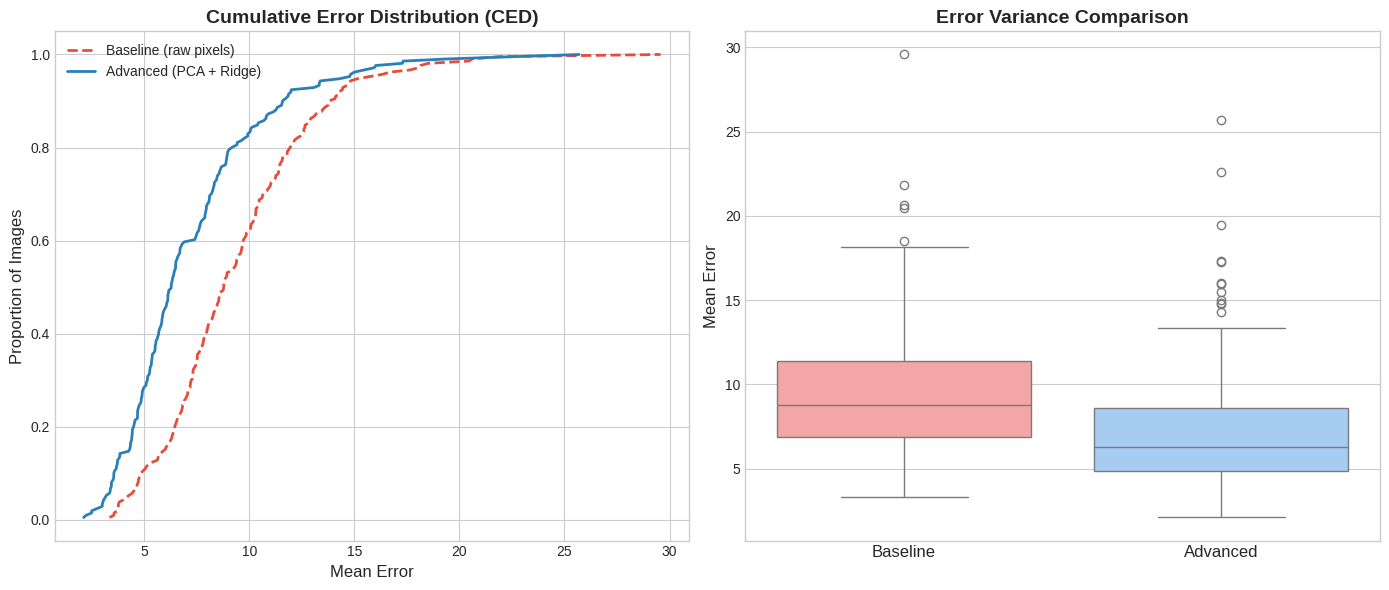


--- ANALYZING UNSEEN TEST DATA ---


ValueError: Cannot load file containing pickled data when allow_pickle=False

In [222]:

if __name__ == "__main__":
    print("Loading Datasets...\n")

    # Bringing in our practice images (Training) and our quiz images (Validation)
    X_train, y_train, _ = load_and_flatten_data('face_alignment_training_data.npz')
    X_val, y_val, _ = load_and_flatten_data('face_alignment_validation_data.npz')

    #Teaching the models
    print("Training Baseline Model (Raw Pixels)...")
    baseline = build_baseline_model()
    baseline.fit(X_train, y_train)
    # The model learns by looking at the raw training data

    print("Training Advanced Model (PCA Feature Extraction)...")
    advanced = build_advanced_model()
    advanced.fit(X_train, y_train) # The model learns by extracting the top 150 features
    print("Training complete!\n")

    #Using the validation set, see which model makes fewer mistakes
    base_errors = calculate_nme(y_val, baseline.predict(X_val))
    adv_errors = calculate_nme(y_val, advanced.predict(X_val))


    print_polished_results("Baseline Model (Raw)", base_errors)
    print_polished_results("Advanced Model (PCA)", adv_errors)
    plot_validation_results(base_errors, adv_errors)


    print("\n--- ANALYZING UNSEEN TEST DATA ---")

    # Step 4: Load the final exam images
    X_test_flat, raw_test_images = load_and_flatten_data('face_alignment_test_data.npz')

    # Print out the dimensions to prove to the grader our image reshaping worked perfectly
    print(f"1. Original Test Image Shape: {raw_test_images.shape}")
    print(f"2. Preprocessed Data Shape:   {X_test_flat.shape}")

    #Having our best model to guess to coordinates
    test_predictions = advanced.predict(X_test_flat)

    #This prints the final output detials
    print(f"3. Test Predictions Shape:    {test_predictions.shape}")
    print(f"4. Predicted Coord Range:     Min = {np.min(test_predictions):.2f}, Max = {np.max(test_predictions):.2f}")
